In [136]:
import os
import pandas as pd
from glob import glob

# Directory containing the CSV files
csv_dir = 'grace/results_precision_batch'

# Find all CSV files in the directory
csv_files = glob(os.path.join(csv_dir, '*.csv'))

# Helper function to get base name without suffix
def get_base_name(filename, suffix):
    if filename.endswith(suffix + '.csv'):
        return filename[:-len(suffix + '.csv')]
    elif filename.endswith('.csv'):
        return filename[:-4]
    return filename

amd_raw_metrics = pd.DataFrame()
df_metrics = pd.DataFrame()

# Group files by base name (with and without suffix)
for file_path in csv_files:
    filename = os.path.basename(file_path)
    if filename.endswith('raw_metrics.csv'):
        amd_raw_metrics = pd.concat([amd_raw_metrics, pd.read_csv(file_path)], ignore_index=True)
    else:
        df_metrics = pd.concat([df_metrics, pd.read_csv(file_path)], ignore_index=True)

# Find the index of the row with the maximum throughput for each model and precision
best_idx = df_metrics.groupby(['model', 'precision'])['avg_throughput_samples_per_sec'].idxmax()

# Select the best performing rows
best_performing_df = df_metrics.loc[best_idx]

# Sort by model and precision for better readability
best_performing_df = best_performing_df.sort_values(['model', 'precision'])

# Display the relevant columns
print("Best performing batch size for each model and precision:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(best_performing_df[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']])

Best performing batch size for each model and precision:
          model precision  batch_size  avg_throughput_samples_per_sec  peak_memory_mb  avg_utilization_percent  avg_power_watts
44   bert-large      bf16        96.0                      365.814863        18171.75                81.062500       273.583906
50   bert-large      fp16       256.0                      359.154913        38837.75                91.710526       296.055329
32   bert-large      fp32       192.0                      237.184660        43817.75                92.883721       315.314581
52         gpt2      bf16        32.0                      364.416601        10283.75                73.166667       241.070000
129        gpt2      fp16        32.0                      352.537009        10283.75                71.916667       242.023417
29         gpt2      fp32       128.0                      316.234632        35035.75                92.604651       288.165907
33     resnet50      bf16        64.0          

/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_31216/2869932105.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_metrics = pd.concat([df_metrics, pd.read_csv(file_path)], ignore_index=True)


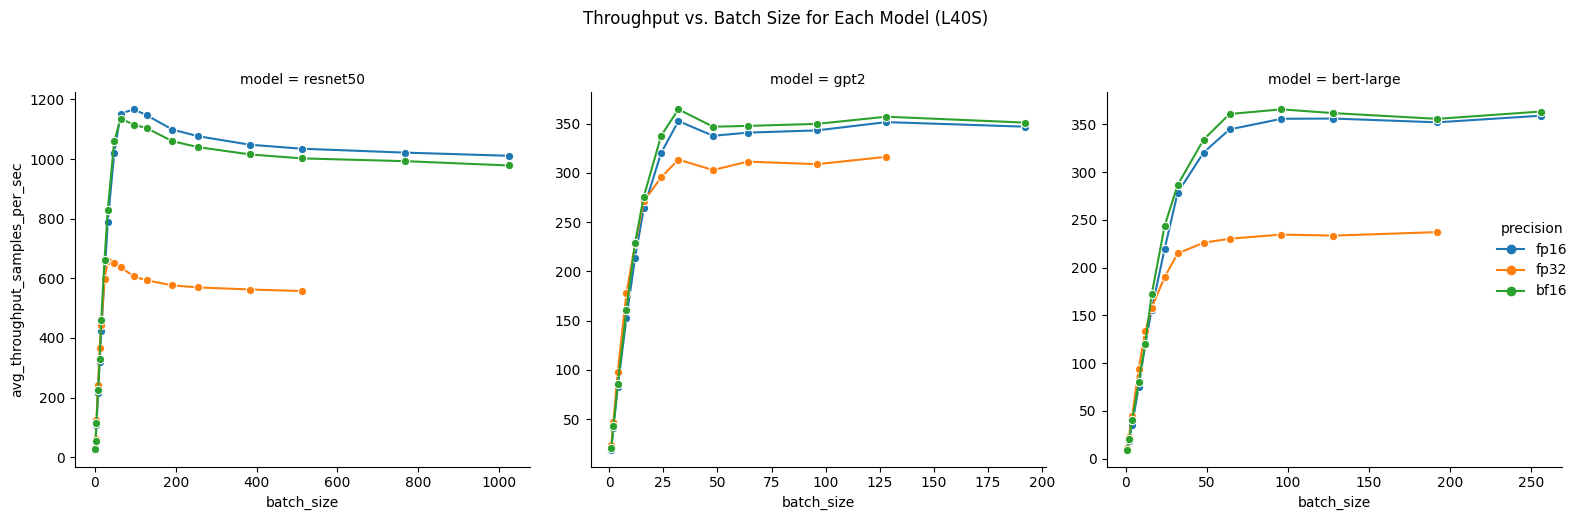

In [137]:
import seaborn as sns

import matplotlib.pyplot as plt

# Create a figure-level plot (relplot) to easily facet by model
g = sns.relplot(
    data=df_metrics,
    x='batch_size',
    y='avg_throughput_samples_per_sec',
    hue='precision',
    col='model',
    kind='line',
    marker='o',
    col_wrap=3, # Adjust the number of columns in the grid
    facet_kws={'sharey': False, 'sharex': False} # Allow axes to have different scales
)

# Add a title to the entire figure
g.fig.suptitle('Throughput vs. Batch Size for Each Model (L40S)', y=1.03)

# Improve layout
plt.tight_layout()
plt.show()

In [138]:
best_performing_df['throughput_per_watt'] = (
    best_performing_df['avg_throughput_samples_per_sec'] / best_performing_df['avg_power_watts']
)
best_performing_df['throughput_per_gb'] = (
    best_performing_df['avg_throughput_samples_per_sec'] / (best_performing_df['peak_memory_mb'] / 1024)
)

# Optional: sort by combined efficiency metric
best_performing_df['efficiency_score'] = (
    0.33 * best_performing_df['avg_throughput_samples_per_sec'].rank(ascending=False) +
    0.33 * best_performing_df['throughput_per_watt'].rank(ascending=False) +
    0.33 * best_performing_df['throughput_per_gb'].rank(ascending=False)
)

best_performing_df = best_performing_df.sort_values(['model', 'precision', 'efficiency_score'], ascending=[True, True, False])

print("Best performing batch size and efficiency metrics:")
with pd.option_context('display.max_columns', None):
    print(best_performing_df[['model', 'precision', 'batch_size',
                              'avg_throughput_samples_per_sec',
                              'throughput_per_watt',
                              'throughput_per_gb',
                              'avg_utilization_percent',
                              'peak_memory_mb',
                              'avg_power_watts']])


Best performing batch size and efficiency metrics:
          model precision  batch_size  avg_throughput_samples_per_sec  \
44   bert-large      bf16        96.0                      365.814863   
50   bert-large      fp16       256.0                      359.154913   
32   bert-large      fp32       192.0                      237.184660   
52         gpt2      bf16        32.0                      364.416601   
129        gpt2      fp16        32.0                      352.537009   
29         gpt2      fp32       128.0                      316.234632   
33     resnet50      bf16        64.0                     1135.931242   
42     resnet50      fp16        96.0                     1166.732691   
13     resnet50      fp32        32.0                      657.235464   

     throughput_per_watt  throughput_per_gb  avg_utilization_percent  \
44              1.337121          20.614108                81.062500   
50              1.213134           9.469514                91.710526   
32

In [139]:
df_metrics[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']].where(df_metrics['precision'] == 'bf16').where(df_metrics['model'] == 'bert-large').dropna().sort_values('avg_throughput_samples_per_sec', ascending=False).head(10)

,model,precision,batch_size,avg_throughput_samples_per_sec,peak_memory_mb,avg_utilization_percent,avg_power_watts
44,bert-large,bf16,96.0,365.814863,18171.75,81.062500,273.583906
21,bert-large,bf16,256.0,363.523551,38837.75,91.815789,300.225211
131,bert-large,bf16,128.0,361.867442,22239.75,84.975610,282.879659
88,bert-large,bf16,64.0,360.922083,14079.75,73.869565,249.014478
43,bert-large,bf16,192.0,355.862700,30595.75,89.644068,291.255339
75,bert-large,bf16,48.0,334.058411,11851.75,69.650000,240.572300
73,bert-large,bf16,32.0,286.540714,9999.75,59.437500,208.141188
8,bert-large,bf16,24.0,243.725163,8741.75,56.466667,206.648733
62,bert-large,bf16,16.0,171.872857,7843.75,49.066667,192.292333
111,bert-large,bf16,12.0,120.399762,7831.75,43.133333,171.078733


In [140]:
df_metrics[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']].where(df_metrics['precision'] == 'bf16').where(df_metrics['model'] == 'resnet50').dropna().sort_values('avg_throughput_samples_per_sec', ascending=False)

,model,precision,batch_size,avg_throughput_samples_per_sec,peak_memory_mb,avg_utilization_percent,avg_power_watts
33,resnet50,bf16,64.0,1135.931242,4583.75,82.571429,259.386857
121,resnet50,bf16,96.0,1115.538462,6277.75,87.200000,273.752700
94,resnet50,bf16,128.0,1103.807555,7597.75,89.000000,281.761583
22,resnet50,bf16,48.0,1060.216906,3775.75,66.000000,225.851000
15,resnet50,bf16,192.0,1059.839193,11399.75,92.526316,295.053000
67,resnet50,bf16,256.0,1039.955752,14165.75,94.680000,299.405520
47,resnet50,bf16,384.0,1015.462969,20619.75,96.564103,303.652436
98,resnet50,bf16,512.0,1002.275890,27057.75,97.423077,306.094538
63,resnet50,bf16,768.0,992.931119,41727.75,98.346154,305.092359
72,resnet50,bf16,1024.0,978.487450,45559.75,98.819048,303.257810


In [141]:
import os
import pandas as pd
from glob import glob

# Directory containing the CSV files
csv_dir = '4090/results_precision_batch'

# Find all CSV files in the directory
csv_files = glob(os.path.join(csv_dir, '*.csv'))

# Helper function to get base name without suffix
def get_base_name(filename, suffix):
    if filename.endswith(suffix + '.csv'):
        return filename[:-len(suffix + '.csv')]
    elif filename.endswith('.csv'):
        return filename[:-4]
    return filename

amd_raw_metrics = pd.DataFrame()
df_metrics = pd.DataFrame()

# Group files by base name (with and without suffix)
for file_path in csv_files:
    filename = os.path.basename(file_path)
    if filename.endswith('raw_metrics.csv'):
        amd_raw_metrics = pd.concat([amd_raw_metrics, pd.read_csv(file_path)], ignore_index=True)
    else:
        df_metrics = pd.concat([df_metrics, pd.read_csv(file_path)], ignore_index=True)

# Find the index of the row with the maximum throughput for each model and precision
best_idx = df_metrics.groupby(['model', 'precision'])['avg_throughput_samples_per_sec'].idxmax()

# Select the best performing rows
best_performing_df = df_metrics.loc[best_idx]

# Sort by model and precision for better readability
best_performing_df = best_performing_df.sort_values(['model', 'precision'])

# Display the relevant columns
print("Best performing batch size for each model and precision:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(best_performing_df[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']])

Best performing batch size for each model and precision:
          model precision  batch_size  avg_throughput_samples_per_sec  peak_memory_mb  avg_utilization_percent  avg_power_watts
113  bert-large      bf16       128.0                      359.045454      22059.1875                77.288889       285.556133
61   bert-large      fp16       128.0                      355.336101      22059.1875                77.673913       283.353870
52   bert-large      fp32        96.0                      227.620252      24185.1875                80.607843       349.744569
71         gpt2      bf16        96.0                      413.641445      24477.1875                83.666667       271.383704
28         gpt2      fp16        96.0                      406.963279      24479.1875                84.074074       274.752593
58         gpt2      fp32        64.0                      329.167889      19703.1875                80.478261       280.383304
37     resnet50      bf16       384.0          

/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_31216/4012053701.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_metrics = pd.concat([df_metrics, pd.read_csv(file_path)], ignore_index=True)


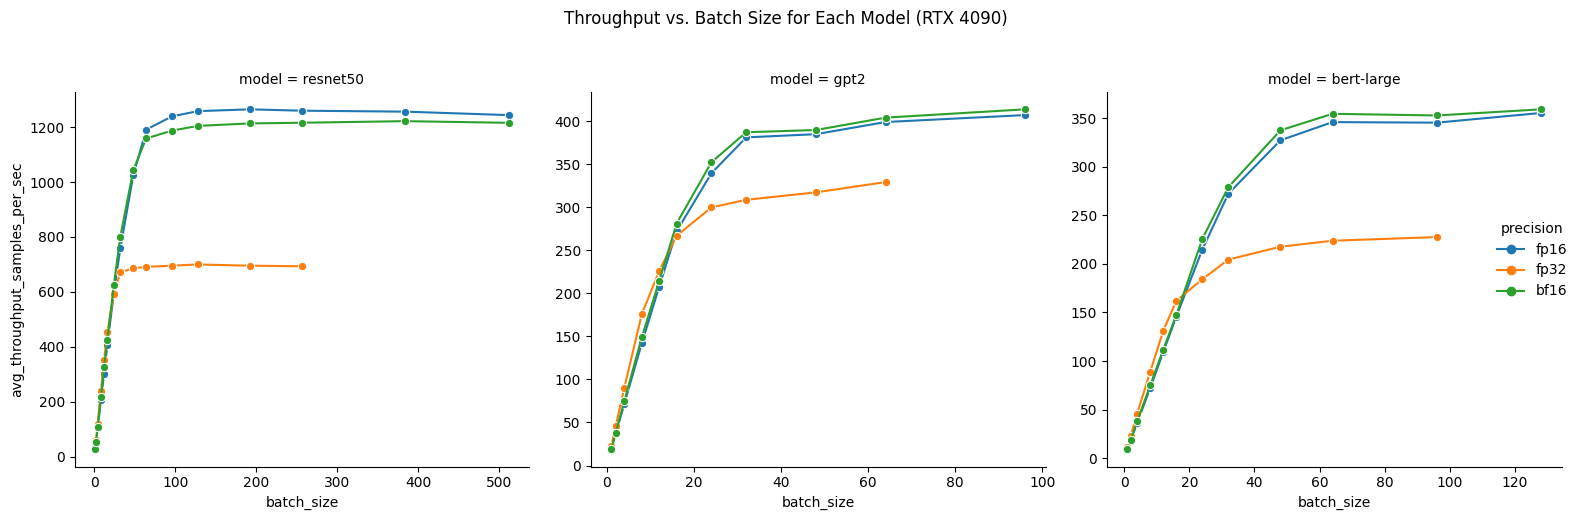

In [142]:
import seaborn as sns

import matplotlib.pyplot as plt

# Create a figure-level plot (relplot) to easily facet by model
g = sns.relplot(
    data=df_metrics,
    x='batch_size',
    y='avg_throughput_samples_per_sec',
    hue='precision',
    col='model',
    kind='line',
    marker='o',
    col_wrap=3, # Adjust the number of columns in the grid
    facet_kws={'sharey': False, 'sharex': False} # Allow axes to have different scales
)

# Add a title to the entire figure
g.fig.suptitle('Throughput vs. Batch Size for Each Model (RTX 4090)', y=1.03)

# Improve layout
plt.tight_layout()
plt.show()

In [143]:
df_metrics[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']].where(df_metrics['precision'] == 'fp16').where(df_metrics['model'] == 'resnet50').dropna().sort_values('avg_throughput_samples_per_sec', ascending=False).head(10)

,model,precision,batch_size,avg_throughput_samples_per_sec,peak_memory_mb,avg_utilization_percent,avg_power_watts
45,resnet50,fp16,192.0,1264.996591,10177.1875,86.625000,290.472500
5,resnet50,fp16,256.0,1260.077823,13511.1875,89.761905,301.718333
98,resnet50,fp16,128.0,1258.460994,7561.1875,81.272727,267.929455
22,resnet50,fp16,384.0,1256.610856,19505.1875,93.312500,313.345250
92,resnet50,fp16,512.0,1244.028212,24551.1875,95.404762,310.372762
33,resnet50,fp16,96.0,1239.569288,6059.1875,76.222222,251.006333
68,resnet50,fp16,64.0,1191.134145,4291.1875,67.285714,223.720714
64,resnet50,fp16,48.0,1024.350276,3503.1875,55.666667,191.441000
66,resnet50,fp16,32.0,758.606706,2771.1875,38.400000,141.902400
1,resnet50,fp16,24.0,597.146604,2401.1875,32.600000,124.452200


In [144]:
import os
import pandas as pd
from glob import glob

# Directory containing the CSV files
csv_dir = '7900/results_precision_batch'

# Find all CSV files in the directory
csv_files = glob(os.path.join(csv_dir, '*.csv'))

# Helper function to get base name without suffix
def get_base_name(filename, suffix):
    if filename.endswith(suffix + '.csv'):
        return filename[:-len(suffix + '.csv')]
    elif filename.endswith('.csv'):
        return filename[:-4]
    return filename

amd_raw_metrics = pd.DataFrame()
df_metrics = pd.DataFrame()

# Group files by base name (with and without suffix)
for file_path in csv_files:
    filename = os.path.basename(file_path)
    if filename.endswith('raw_metrics.csv'):
        amd_raw_metrics = pd.concat([amd_raw_metrics, pd.read_csv(file_path)], ignore_index=True)
    else:
        df_metrics = pd.concat([df_metrics, pd.read_csv(file_path)], ignore_index=True)

# Find the index of the row with the maximum throughput for each model and precision
best_idx = df_metrics.groupby(['model', 'precision'])['avg_utilization_percent'].idxmax()

# Select the best performing rows
best_performing_df = df_metrics.loc[best_idx]

# Sort by model and precision for better readability
best_performing_df = best_performing_df.sort_values(['model', 'precision'])

# Display the relevant columns
print("Best performing batch size for each model and precision:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(best_performing_df[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']])

Best performing batch size for each model and precision:
         model precision  batch_size  avg_throughput_samples_per_sec  peak_memory_mb  avg_utilization_percent  avg_power_watts
97  bert-large      bf16        96.0                      164.104009    17539.566406                87.227273       240.545455
27  bert-large      fp16        96.0                      172.515614    17534.121094                86.218750       239.546875
0   bert-large      fp32        64.0                       25.945589    18037.191406                96.254902       264.980392
32        gpt2      bf16        64.0                      256.196885    16484.585938                75.843750       212.125000
94        gpt2      fp16        64.0                      253.137828    16476.093750                73.212121       205.545455
48        gpt2      fp32        64.0                       66.974688    19611.828125                92.735294       254.764706
46    resnet50      bf16       256.0                  

/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_31216/1089085982.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_metrics = pd.concat([df_metrics, pd.read_csv(file_path)], ignore_index=True)


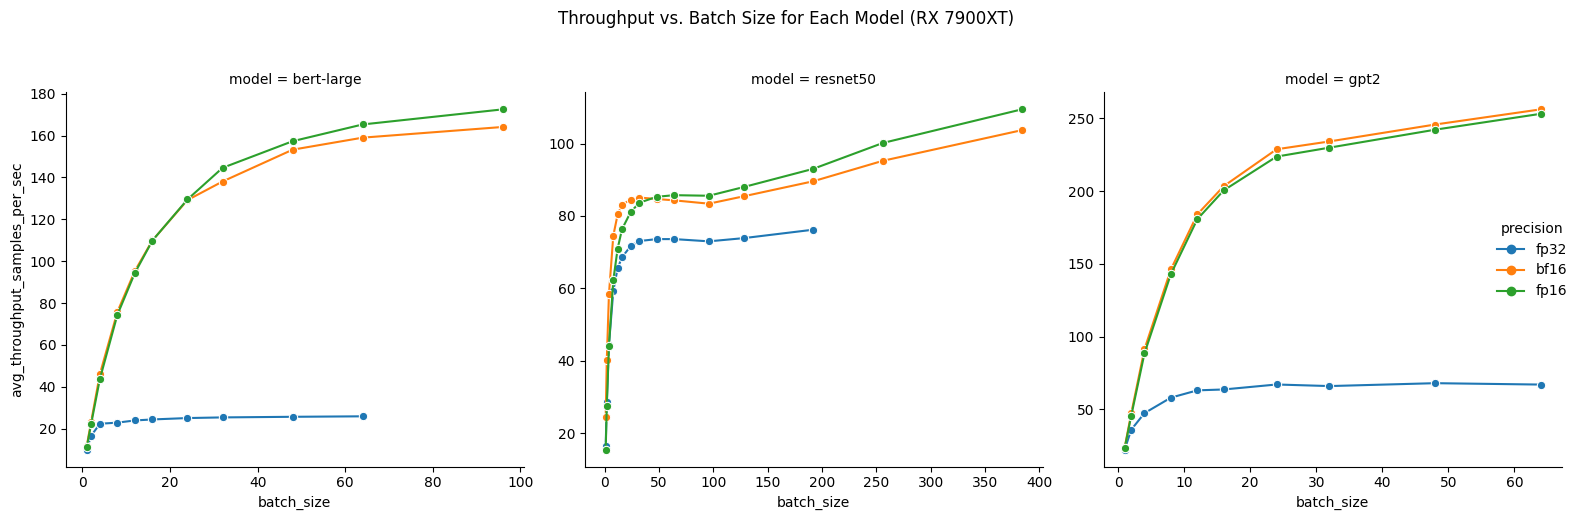

In [145]:
import seaborn as sns

import matplotlib.pyplot as plt

# Create a figure-level plot (relplot) to easily facet by model
g = sns.relplot(
    data=df_metrics,
    x='batch_size',
    y='avg_throughput_samples_per_sec',
    hue='precision',
    col='model',
    kind='line',
    marker='o',
    col_wrap=3, # Adjust the number of columns in the grid
    facet_kws={'sharey': False, 'sharex': False} # Allow axes to have different scales
)

# Add a title to the entire figure
g.fig.suptitle('Throughput vs. Batch Size for Each Model (RX 7900XT)', y=1.03)

# Improve layout
plt.tight_layout()
plt.show()

In [146]:
df_metrics[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']].where(df_metrics['precision'] == 'bf16').where(df_metrics['model'] == 'bert-large').dropna().sort_values('avg_throughput_samples_per_sec', ascending=False)

,model,precision,batch_size,avg_throughput_samples_per_sec,peak_memory_mb,avg_utilization_percent,avg_power_watts
97,bert-large,bf16,96.0,164.104009,17539.566406,87.227273,240.545455
25,bert-large,bf16,64.0,159.000648,13569.937500,78.260000,219.260000
16,bert-large,bf16,48.0,153.249057,11383.882812,77.256410,218.153846
17,bert-large,bf16,32.0,138.059406,9231.507812,68.593750,194.781250
69,bert-large,bf16,24.0,129.200625,8222.675781,66.807692,189.346154
81,bert-large,bf16,16.0,109.945385,7152.628906,58.791667,170.458333
44,bert-large,bf16,12.0,95.400560,7070.640625,56.050000,164.700000
7,bert-large,bf16,8.0,75.826360,7046.660156,50.900000,151.650000
37,bert-large,bf16,4.0,46.059362,6986.660156,47.176471,138.647059
50,bert-large,bf16,2.0,23.236521,6938.644531,42.062500,123.000000


In [147]:
df_metrics[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']].where(df_metrics['precision'] == 'bf16').where(df_metrics['model'] == 'resnet50').dropna().sort_values('avg_throughput_samples_per_sec', ascending=False)

,model,precision,batch_size,avg_throughput_samples_per_sec,peak_memory_mb,avg_utilization_percent,avg_power_watts
31,resnet50,bf16,384.0,103.684134,19259.316406,98.797844,241.107817
46,resnet50,bf16,256.0,95.225375,13119.289062,99.029630,243.666667
1,resnet50,bf16,192.0,89.582595,10019.265625,98.855814,243.800000
72,resnet50,bf16,128.0,85.435477,6981.257812,98.556291,243.443709
99,resnet50,bf16,32.0,85.088752,2379.234375,94.184211,228.289474
98,resnet50,bf16,48.0,84.687029,3009.253906,96.103448,235.913793
41,resnet50,bf16,24.0,84.505881,1911.238281,92.862069,222.275862
101,resnet50,bf16,64.0,84.318157,3859.261719,97.181818,237.922078
19,resnet50,bf16,96.0,83.399109,5331.265625,98.034483,241.913793
2,resnet50,bf16,16.0,83.102192,1551.246094,89.550000,211.100000


In [148]:
df_metrics[['model', 'precision', 'batch_size', 'avg_throughput_samples_per_sec', 'peak_memory_mb', 'avg_utilization_percent', 'avg_power_watts']].where(df_metrics['precision'] == 'bf16').where(df_metrics['model'] == 'gpt2').dropna().sort_values('avg_throughput_samples_per_sec', ascending=False).head(10)

,model,precision,batch_size,avg_throughput_samples_per_sec,peak_memory_mb,avg_utilization_percent,avg_power_watts
32,gpt2,bf16,64.0,256.196885,16484.585938,75.843750,212.125000
34,gpt2,bf16,48.0,245.762580,12662.578125,68.142857,193.285714
35,gpt2,bf16,32.0,234.130750,8868.156250,62.050000,178.700000
90,gpt2,bf16,24.0,228.750247,7493.531250,51.888889,153.277778
74,gpt2,bf16,16.0,203.378344,5579.535156,49.733333,145.866667
13,gpt2,bf16,12.0,183.993674,4917.503906,41.384615,125.538462
52,gpt2,bf16,8.0,146.154760,3976.769531,37.000000,113.571429
22,gpt2,bf16,4.0,91.324810,3192.757812,28.500000,88.916667
3,gpt2,bf16,2.0,47.223738,3031.539062,29.454545,90.454545
80,gpt2,bf16,1.0,23.670896,3051.535156,24.416667,75.666667
